In [40]:
import requests
import json

In [72]:
# 네이버 데이터랩 API URL
url = "https://openapi.naver.com/v1/datalab/search"

# API 요청 헤더
headers = {
    "Content-Type": "application/json",
    "X-Naver-Client-Id": "7a9wMrFFtLspGJr5wq4v",      # 발급받은 Client ID
    "X-Naver-Client-Secret": "hm_l0prduQ"  # 발급받은 Client Secret
}


def search_naver(_start, _end, _unit, _group, _keyword):
    groups = []
    for i in range(len(_group)):
        groups.append(
            {
                'groupName' : _group[i], 
                'keywords' : _keyword[i]
            }
        )
    # API 요청 데이터
    data = {
        "startDate": _start,
        "endDate": _end,
        "timeUnit": _unit,
        "keywordGroups": groups
    }

    # API 호출
    response = requests.post(url, headers=headers, data=json.dumps(data))

    # 응답 확인
    if response.status_code == 200:
        result = response.json()
        print(json.dumps(result, indent=4, ensure_ascii=False))
    else:
        print("Error Code:", response.status_code)
    
    return result


In [42]:
import pandas as pd

In [82]:
result1 = search_naver('2024-01-01', '2024-06-30', 'month', 
                       ['후백', '경조사'],
                        [
                            ['호두강정세트'], 
                            ['호두강정 선물']
                        ]
                        )

{
    "startDate": "2024-01-01",
    "endDate": "2024-06-30",
    "timeUnit": "month",
    "results": [
        {
            "title": "후백",
            "keywords": [
                "호두강정세트"
            ],
            "data": [
                {
                    "period": "2024-01-01",
                    "ratio": 11.62162
                },
                {
                    "period": "2024-02-01",
                    "ratio": 2.7027
                }
            ]
        },
        {
            "title": "경조사",
            "keywords": [
                "호두강정 선물"
            ],
            "data": [
                {
                    "period": "2024-01-01",
                    "ratio": 60.54054
                },
                {
                    "period": "2024-02-01",
                    "ratio": 100
                },
                {
                    "period": "2024-03-01",
                    "ratio": 34.05405
                },
                {
              

In [83]:
df1 = pd.DataFrame(result1['results'][0]['data'])
df2 = pd.DataFrame(result1['results'][1]['data'])

In [84]:
df1['keyword'] = str(result1['results'][0]['keywords'])

In [85]:
df2['keyword'] = str(result1['results'][1]['keywords'])

In [86]:
df1

,period,ratio,keyword
0,2024-01-01,11.62162,['호두강정세트']
1,2024-02-01,2.70270,['호두강정세트']


In [87]:
df2

,period,ratio,keyword
0,2024-01-01,60.54054,['호두강정 선물']
1,2024-02-01,100.00000,['호두강정 선물']
2,2024-03-01,34.05405,['호두강정 선물']
3,2024-04-01,60.54054,['호두강정 선물']
4,2024-05-01,85.13513,['호두강정 선물']
5,2024-06-01,27.29729,['호두강정 선물']


In [88]:
호두강정_선물 = df2.copy()

In [89]:
호두정과_답례품 

,period,ratio,keyword
0,2024-01-01,18.40624,['호두정과 답례품']
1,2024-02-01,29.58501,['호두정과 답례품']
2,2024-03-01,17.66496,['호두정과 답례품']
3,2024-04-01,100.00000,['호두정과 답례품']
4,2024-05-01,30.84916,['호두정과 답례품']
5,2024-06-01,31.95446,['호두정과 답례품']


In [90]:
호두강정_선물

,period,ratio,keyword
0,2024-01-01,60.54054,['호두강정 선물']
1,2024-02-01,100.00000,['호두강정 선물']
2,2024-03-01,34.05405,['호두강정 선물']
3,2024-04-01,60.54054,['호두강정 선물']
4,2024-05-01,85.13513,['호두강정 선물']
5,2024-06-01,27.29729,['호두강정 선물']


# 네이버 검색광고 API

In [2]:
import os
import sys
import urllib.request
import json
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import requests


import hashlib
import hmac
import base64


class Signature:

    @staticmethod
    def generate(timestamp, method, uri, secret_key):
        message = "{}.{}.{}".format(timestamp, method, uri)
        hash = hmac.new(bytes(secret_key, "utf-8"), bytes(message, "utf-8"), hashlib.sha256)
        
        hash.hexdigest()
        return base64.b64encode(hash.digest())
    

def get_header(method, uri, api_key, secret_key, customer_id):
    timestamp = str(round(time.time() * 1000))
    signature = Signature.generate(timestamp, method, uri, secret_key)
    
    return {'Content-Type': 'application/json; charset=UTF-8', 'X-Timestamp': timestamp, 
            'X-API-KEY': api_key, 'X-Customer': str(customer_id), 'X-Signature': signature}


def getresults(hintKeywords):

    BASE_URL = 'https://api.naver.com'
    API_KEY = '01000000001032b275c4a11023163abc8cac104361a576d200ab4a9a23d67951da6acf6b16'
    SECRET_KEY = 'AQAAAABt5vCTU15L+VltnmUaN4afh/Bvxoxg32TcV7BzFnpBdQ=='
    CUSTOMER_ID = '2961292'

    uri = '/keywordstool'
    method = 'GET'

    params={}

    params['hintKeywords']=hintKeywords
    params['showDetail']='1'

    r=requests.get(BASE_URL + uri, params=params, 
                 headers=get_header(method, uri, API_KEY, SECRET_KEY, CUSTOMER_ID))

    df = pd.DataFrame(r.json()['keywordList'])

    # 컬럼명을 변경
    df.rename(columns={
        'relKeyword': '연관키워드',
        'monthlyPcQcCnt': '월간검색수(PC)',
        'monthlyMobileQcCnt': '월간검색수(모바일)',
        'monthlyAvePcClkCnt': '월평균클릭수(PC)',
        'monthlyAveMobileClkCnt': '월평균클릭수(모바일)',
        'monthlyAvePcCtr': '월평균클릭률(PC)',
        'monthlyAveMobileCtr': '월평균클릭률(모바일)',
        'plAvgDepth': '월평균노출광고수',
        'compIdx': '경쟁정도'
    }, inplace=True)
    
    return df

In [3]:
key1 = ['호두강정']

resultdf = getresults(key1)
resultdf

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
0,호두강정,2160,10900,18.0,139.6,0.86,1.36,7,높음
1,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
2,호두정과답례품,2360,11700,9.9,191.6,0.44,1.77,15,높음
3,호두강정답례품,650,2960,4.6,64.8,0.74,2.40,15,높음
4,답례품호두정과,120,720,4.3,25.0,3.73,3.67,7,높음
...,...,...,...,...,...,...,...,...,...
483,신부님선물,30,350,0.0,1.5,0.00,0.47,3,중간
484,미니양갱,130,390,0.9,19.0,0.65,5.14,7,높음
485,수제답례품,20,60,0.3,3.0,1.15,4.48,7,높음
486,임당간식,150,1340,0.4,7.3,0.29,0.58,7,높음


#### 현재 설정한 PC파워링크 키워드 중 노출수 0인 키워드 데이터 확인
- 목록 [ 결혼답례품견과류, 결혼답례품호두강정, 결혼답례품호두정과, 답례품호두강정, 답례품호두정과, 답례호두강정, 답례호두정과, 호두강정선물세트, 호두답례품, 호두정과답례, 호두정과선물, 호두정과선물세트 ]


In [4]:
import time
import pandas as pd

# 노출수0인 키워드 목록
effect0 = [
    '결혼답례품견과류', '결혼답례품호두강정', '결혼답례품호두정과', '답례품호두강정',
    '답례품호두정과', '답례호두강정', '답례호두정과', '호두강정선물세트',
    '호두답례품', '호두정과답례', '호두정과선물', '호두정과선물세트'
]

# 첫 번째 키워드에 대한 데이터프레임 생성
effect0_df = getresults(effect0[0]).iloc[0].to_frame().T

# 나머지 키워드에 대해 데이터프레임을 순회하면서 df1에 추가
for keyword in effect0[1:]:
    df_temp = getresults(keyword).iloc[0].to_frame().T
    effect0_df = pd.concat([effect0_df, df_temp], axis=0, ignore_index=True)
    time.sleep(1)  # 1초 간격으로 API 호출 간격을 줌



### 확인결과 월간 검색수가 200회도 넘지않는 저급의 키워드인것을 확인

In [5]:
effect0_df

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
0,결혼답례품견과류,60,160,1.1,7.3,1.74,4.97,7,높음
1,결혼답례품호두강정,< 10,30,0.0,1.8,0.0,5.0,7,높음
2,결혼답례품호두정과,60,90,1.6,3.3,2.39,3.74,7,높음
3,답례품호두강정,100,390,0.9,4.3,0.86,1.11,7,높음
4,답례품호두정과,120,720,4.3,25.0,3.73,3.67,7,높음
5,답례호두강정,< 10,30,0.0,0.3,0.0,1.15,3,높음
6,답례호두정과,20,50,0.0,0.3,0.0,0.61,3,높음
7,호두강정선물세트,10,30,0.1,1.0,1.59,3.13,7,높음
8,호두답례품,60,320,1.7,14.0,2.56,4.46,7,높음
9,호두정과답례,30,120,1.0,3.5,2.57,2.97,7,높음


### 현재 pc파워링크의 유의미한 결과를 보이는 키워드 확인

In [6]:
effect1 = ['호두정과','호두정과답례품','호두강정','호두강정답례품']

# 첫 번째 키워드에 대한 데이터프레임 생성
effect1_df = getresults(effect1[0]).iloc[0].to_frame().T

# 나머지 키워드에 대해 데이터프레임을 순회하면서 df1에 추가
for keyword in effect1[1:]:
    df_temp = getresults(keyword).iloc[0].to_frame().T
    effect1_df = pd.concat([effect1_df, df_temp], axis=0, ignore_index=True)
    time.sleep(0.7)  # 1초 간격으로 API 호출 간격을 줌

In [7]:
effect1_df

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
0,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
1,호두정과답례품,2360,11700,9.9,191.6,0.44,1.77,15,높음
2,호두강정,2160,10900,18.0,139.6,0.86,1.36,7,높음
3,호두강정답례품,650,2960,4.6,64.8,0.74,2.4,15,높음


### 6.26 ~7.13 파워링크 모바일 노출도결과


In [8]:
power_result = pd.read_excel('/Users/kang_hiee/Documents/강희/유비온/최종프로젝트/키워드분석/모바일~7_13_노출도_결과.xlsx')
power_result = power_result.iloc[1:,:]
power_result.head(1)

,키워드 ID,상태,키워드,입찰가 유형,입찰가,품질지수,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",전환수,전환율(%),전환매출액,광고수익률(%),전환당비용(원)
1,nkw-a001-01-000006337857246,노출가능,결혼답례품견과류,기본,70.0,4.0,0,0,0.0,0,0,0,0,0,0,0


### effect1 키워드 현황

In [9]:
effect1_result = power_result.loc[power_result['키워드'].isin(effect1)]
effect1_result = effect1_result.sort_values(by='노출수', ascending=False)
effect1_result

,키워드 ID,상태,키워드,입찰가 유형,입찰가,품질지수,노출수,클릭수,클릭률(%),"평균클릭비용(VAT포함,원)","총비용(VAT포함,원)",전환수,전환율(%),전환매출액,광고수익률(%),전환당비용(원)
19,nkw-a001-01-000006337857217,노출가능,호두정과,키워드,1000.0,5.0,8783,76,0.87,978,74338,0,0,0,0,0
18,nkw-a001-01-000006337857220,노출가능,호두정과답례품,키워드,1000.0,5.0,7853,38,0.49,1056,40117,0,0,0,0,0
17,nkw-a001-01-000006337857222,노출가능,호두강정,키워드,1000.0,4.0,4613,20,0.44,1007,20130,0,0,0,0,0
16,nkw-a001-01-000006337857224,노출가능,호두강정답례품,키워드,1000.0,4.0,631,2,0.32,770,1540,0,0,0,0,0


<Axes: xlabel='키워드', ylabel='노출수'>

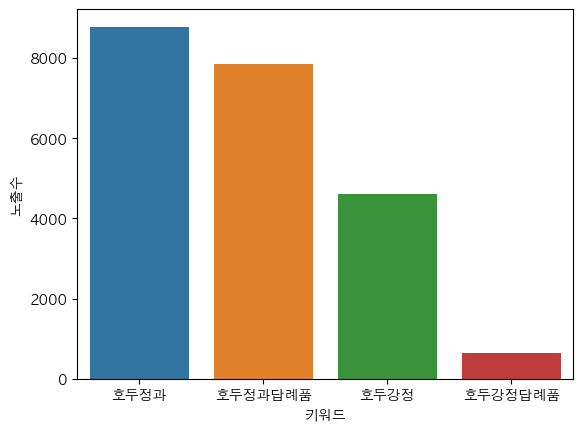

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# AppleGothic 폰트를 설정합니다.
plt.rcParams['font.family'] = 'AppleGothic'

# 한글 사용을 위해 마이너스 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
sns.barplot(effect1_result, x ='키워드', y='노출수')

### 효과있는 키워드의 노출도와 검색량 합친 데이터프레임 만들기

In [11]:
effect1_combine = effect1_result[['키워드','입찰가','노출수','클릭수']].reset_index(drop=True)
effect1_combine = pd.merge(effect1_combine,effect1_df, left_on='키워드',right_on='연관키워드')

In [12]:
effect1_combine

,키워드,입찰가,노출수,클릭수,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
0,호두정과,1000.0,8783,76,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
1,호두정과답례품,1000.0,7853,38,호두정과답례품,2360,11700,9.9,191.6,0.44,1.77,15,높음
2,호두강정,1000.0,4613,20,호두강정,2160,10900,18.0,139.6,0.86,1.36,7,높음
3,호두강정답례품,1000.0,631,2,호두강정답례품,650,2960,4.6,64.8,0.74,2.4,15,높음


In [13]:
effect1_combine.to_csv('effect_combine.csv')

### 그러면 위에 표로 봤을때는 
- 경쟁정도가 낮음~중간
- 월간 검색수가 높은 키워드
- 노출광고수가 적은 키워드
### 가 노출이 잘된다?
그리고 클릭률은 여기에 더해서 우리상품과 관련있는 키워드

### --------------------------------------

### 그럼 일단 우리제품과 연관있는 키워드 중에서 검색량이 많은 키워드를 찾아보자
- 네이버 검색 API를 통해 연관키워드를 뽑고 최근 한달간에 검색량을 보자

In [14]:
import pandas as pd

def process_keyword(keyword):
    # getresults 함수 호출하여 데이터프레임 생성
    df = getresults(keyword)
    
    # '월간검색수(모바일)' 컬럼을 문자열로 변환
    df['월간검색수(모바일)'] = df['월간검색수(모바일)'].astype(str)
    
    # '< ' 문자를 제거
    df['월간검색수(모바일)'] = df['월간검색수(모바일)'].str.replace('< ', '')
    
    # 데이터를 숫자형(int)으로 변환
    df['월간검색수(모바일)'] = df['월간검색수(모바일)'].astype(int)
    
    # '월간검색수(모바일)' 기준으로 내림차순 정렬
    df = df.sort_values(by='월간검색수(모바일)', ascending=False)
    
    # '월간검색수(모바일)'이 10000보다 큰 값 필터링
    result_df = df.loc[df['월간검색수(모바일)'] > 7000]

    # '경쟁정도'가 낮음 이거나 중간 필터링
    #result_df = result_df.loc[(result_df['경쟁정도']=='낮음')|(result_df['경쟁정도']=='중간')]
    
    return result_df


In [15]:
effect1_호두강정 = process_keyword('호두강정')
effect1_호두강정

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
418,장인약과,4550,30900,12.4,239.8,0.28,0.82,7,높음
280,오란다,6170,26900,25.6,472.5,0.43,1.87,15,높음
230,돌답례품,2450,25000,16.7,513.6,0.71,2.21,15,높음
223,바,2620,24700,1.7,54.0,0.07,0.24,7,높음
1,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
296,결혼식답례품,4150,22700,26.3,304.4,0.66,1.43,15,높음
215,단백질바,4660,19500,15.5,284.4,0.35,1.55,15,높음
2,호두정과답례품,2360,11700,9.9,191.6,0.44,1.77,15,높음
210,에너지바,2780,11200,8.7,318.8,0.33,3.01,15,높음
229,호두효능,1190,11100,1.9,168.0,0.17,1.61,7,높음


In [16]:
#호두정과답례품
effect1_호두정과답례품 = process_keyword('호두정과답례품')
effect1_호두정과답례품

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
22,호두과자,3970,32700,34.2,346.2,0.89,1.14,10,중간
162,돌답례품,2450,25000,16.7,513.6,0.71,2.21,15,높음
1,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
264,결혼식답례품,4150,22700,26.3,304.4,0.66,1.43,15,높음
356,퇴사선물,4160,16800,5.1,70.5,0.13,0.44,7,높음
0,호두정과답례품,2360,11700,9.9,191.6,0.44,1.77,15,높음
284,천안호두과자,1430,11700,15.1,272.2,1.09,2.56,10,중간
160,호두효능,1190,11100,1.9,168.0,0.17,1.61,7,높음
3,호두강정,2160,10900,18.0,139.6,0.86,1.36,7,높음
407,홍대입구맛집,1110,10100,3.1,75.8,0.29,0.81,7,높음


In [17]:
#결혼답례품
effect1_결혼답례품 = process_keyword('결혼답례품')
effect1_결혼답례품

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
46,침향,4380,41500,18.0,704.2,0.43,1.82,10,중간
637,생일선물,5410,31700,7.7,150.5,0.15,0.51,7,높음
20,침향환,3970,31000,46.4,692.0,1.21,2.39,10,높음
63,침향환효능,2110,27100,12.1,1223.2,0.59,4.82,15,높음
15,돌답례품,2450,25000,16.7,513.6,0.71,2.21,15,높음
828,개업선물,4270,24800,13.3,166.5,0.32,0.72,7,높음
74,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
1,결혼식답례품,4150,22700,26.3,304.4,0.66,1.43,15,높음
897,생일,3500,22600,2.6,57.8,0.08,0.28,7,높음
6,호텔수건,3090,21500,16.6,459.8,0.56,2.30,10,중간


### 기존 키워드와 스토어 상품과 관련없는 키워드 제외 and 경쟁정도 낮음~중간
- 돌잔치답례품
- 어린이집답례품
-> 하지만 입찰가가 2000~3000원 이므로 너무 비싸서 탈락
-> 1000원 이하로 구해야함

In [18]:
effect1_결혼답례품.reset_index(drop=True, inplace=True)
effect1_결혼답례품

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
0,침향,4380,41500,18.0,704.2,0.43,1.82,10,중간
1,생일선물,5410,31700,7.7,150.5,0.15,0.51,7,높음
2,침향환,3970,31000,46.4,692.0,1.21,2.39,10,높음
3,침향환효능,2110,27100,12.1,1223.2,0.59,4.82,15,높음
4,돌답례품,2450,25000,16.7,513.6,0.71,2.21,15,높음
5,개업선물,4270,24800,13.3,166.5,0.32,0.72,7,높음
6,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
7,결혼식답례품,4150,22700,26.3,304.4,0.66,1.43,15,높음
8,생일,3500,22600,2.6,57.8,0.08,0.28,7,높음
9,호텔수건,3090,21500,16.6,459.8,0.56,2.30,10,중간


In [44]:
# 테스트해볼 키워드 리스트 삽입
effect_keyword = ['어린이집답례품','돌잔치답례품']
# 하지만 입찰가가 너무 높음

In [27]:
# 답례품
effect1_호두강정선물세트 = process_keyword('호두강정선물세트')
effect1_호두강정선물세트 


,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
5,견과류,9680,49600,44.3,897.4,0.47,1.93,15,높음
6,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
12,호두정과답례품,2360,11700,9.9,191.6,0.44,1.77,15,높음
10,호두강정,2160,10900,18.0,139.6,0.86,1.36,7,높음
138,견과류종류,1060,9420,5.5,429.3,0.54,4.86,15,높음
32,설날,5280,8760,1.6,5.5,0.04,0.07,7,높음


In [47]:
new_keydf = pd.read_excel('/Users/kang_hiee/Documents/강희/유비온/최종프로젝트/키워드분석/키워드목록.xlsx')
new_keylist = new_keydf['키워드목록'].tolist()
new_keylist

['호두정과',
 '호두강정답례',
 '호두정과추천',
 '견과류강정',
 '센스있는답례품',
 '돌답례',
 '골프칠때간식',
 '호두정과세트',
 '결혼답례선물',
 '결혼답례품쇼핑몰',
 '견과류답례품',
 '답례품견과류',
 '결혼답례품호두',
 '환갑답례품',
 '견과류선물',
 '결혼식장답례품',
 '유치원간식답례품',
 '어린이집답례간식',
 '조문답례품추천',
 '어르신간식선물',
 '결혼식답례품순위',
 '결혼식답례품포장',
 '견과류선물세트',
 '수제강정',
 '부모님간식',
 '골프간식',
 '산모에게좋은음식',
 '견과류간식',
 '산모선물',
 '견과류세트',
 '영양간식추천',
 '꿀호두',
 '아이들영양간식',
 '몸에좋은견과류',
 '무설탕호두강정',
 '수제호두정과',
 '결혼감사선물',
 '결혼후선물',
 '돌답례품견과류',
 '골프라운딩간식',
 '골프장간식',
 '어른간식',
 '임산부에게좋은선물',
 '견과류세트선물',
 '고3간식',
 '고급간식',
 '고급견과류세트',
 '견과선물세트',
 '답례품견과',
 '견과류답례',
 '답례품간식',
 '결혼답례품추천',
 '돌잔치답례선물',
 '답례품결혼',
 '답례품세트',
 '승진축하선물',
 '결혼식답례',
 '돌답례선물',
 '고급돌답례품',
 '답례품선물',
 '답례품전문',
 '팔순답례품',
 '소량답례품',
 '간식답례품',
 '답례간식',
 '간식선물']

In [53]:
import pandas as pd
import time

def collect_keyword_data(keywords, wait_time=0.7):
    """
    주어진 키워드 목록에 대해 데이터를 수집하고 데이터프레임으로 반환합니다.

    Parameters:
    keywords (list): 키워드 목록
    wait_time (float): API 호출 간격 (초), 기본값은 0.7초

    Returns:
    pd.DataFrame: 수집된 데이터를 포함한 데이터프레임
    """
    # 첫 번째 키워드에 대한 데이터프레임 생성
    result_df = getresults(keywords[0]).iloc[0].to_frame().T

    # 나머지 키워드에 대해 데이터프레임을 순회하면서 추가
    for keyword in keywords[1:]:
        df_temp = getresults(keyword).iloc[0].to_frame().T
        result_df = pd.concat([result_df, df_temp], axis=0, ignore_index=True)
        time.sleep(wait_time)  # 호출 간격 유지
            # '월간검색수(모바일)' 컬럼을 문자열로 변환
        result_df['월간검색수(모바일)'] = result_df['월간검색수(모바일)'].astype(str)
    
    # '< ' 문자를 제거
        result_df['월간검색수(모바일)'] = result_df['월간검색수(모바일)'].str.replace('< ', '')
    
    # 데이터를 숫자형(int)으로 변환
        result_df['월간검색수(모바일)'] = result_df['월간검색수(모바일)'].astype(int)
    
    # '월간검색수(모바일)' 기준으로 내림차순 정렬
        result_df = result_df.sort_values(by='월간검색수(모바일)', ascending=False)
    
    # '월간검색수(모바일)'이 10000보다 큰 값 필터링
        #result_df = result_df.loc[result_df['월간검색수(모바일)'] > 7000]

    return result_df

    

In [57]:
# 사용 예시

final_df = collect_keyword_data(new_keylist)
final_df.to_csv('메인키워드.csv')

In [56]:
final_df_TOP10 = final_df.iloc[:10]
final_df_TOP10

,연관키워드,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),월평균노출광고수,경쟁정도
0,호두정과,5510,24100,44.2,275.0,0.83,1.24,8,중간
1,산모에게좋은음식,360,5910,0.5,178.0,0.16,3.21,15,높음
2,견과류답례품,830,5770,5.0,117.6,0.62,2.18,15,높음
3,센스있는답례품,170,5670,1.9,40.8,1.05,0.77,7,높음
4,산모선물,870,3960,0.9,21.8,0.11,0.59,7,높음
65,간식선물,840,3450,4.1,42.3,0.5,1.28,7,높음
5,견과류세트,700,3290,3.1,109.4,0.46,3.52,15,높음
6,승진축하선물,1180,3170,6.6,50.0,0.56,1.62,7,높음
7,골프간식,590,2740,3.6,63.3,0.62,2.47,7,높음
8,답례품선물,270,2600,2.0,39.5,0.75,1.62,7,높음


In [61]:
# 견과류세트(모바일 840원,PC 720원 ), 골프간식(모바일 1650원, PC단가 870원)
# -> 현재 이 두개를 선정하였지만 단순히 메인키워드 선정후 월간검색수와 입찰가만 필터링거쳐서 나온 키워드이다.

## 30대 여성의 트렌드 검색 네이버 데이터랩 API사용

In [73]:
# 네이버 데이터랩 API URL
url = "https://openapi.naver.com/v1/datalab/search"

# API 요청 헤더
headers = {
    "Content-Type": "application/json",
    "X-Naver-Client-Id": "7a9wMrFFtLspGJr5wq4v",      # 발급받은 Client ID
    "X-Naver-Client-Secret": "hm_l0prduQ"  # 발급받은 Client Secret
}


def search_naver(_start, _end, _unit, _group, _keyword):
    groups = []
    for i in range(len(_group)):
        groups.append(
            {
                'groupName' : _group[i], 
                'keywords' : _keyword[i]
            }
        )
    # API 요청 데이터
    data = {
        "startDate": _start,
        "endDate": _end,
        "timeUnit": _unit,
        "keywordGroups": groups
    }

    # API 호출
    response = requests.post(url, headers=headers, data=json.dumps(data))

    # 응답 확인
    if response.status_code == 200:
        result = response.json()
        print(json.dumps(result, indent=4, ensure_ascii=False))
    else:
        print("Error Code:", response.status_code)
    
    return result


In [ ]:
"Content-Type": "application/json",
    "X-Naver-Client-Id": "7a9wMrFFtLspGJr5wq4v",      # 발급받은 Client ID
    "X-Naver-Client-Secret": "hm_l0prduQ"  # 발급받은 Client Secretㅍㅍ